# <center> Module 4-2: Regression <br>K-Nearest Neighbours on the GPA Dataset </center>
<center>by: Nicole Woodland, P. Eng. for RoboGarden Inc. </center>

---

In this noteook, we will perform K-Nearest Neighbours Regression on the GPA dataset. Always start Machine Learning by <b> Asking the Right Question! </b>

<br><center> Can we predict a University grade point average (GPA) for a student based on their High School GPA in a meaningful way? </center>

## Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

## Read csv file into a dataframe

In [29]:
df = pd.read_csv("../gpa.csv")

In [31]:
df.head(5)

,high_GPA,univ_GPA
0,3.45,3.52
1,2.78,2.91
2,2.52,2.40
3,3.67,3.47
4,3.24,3.47


In [33]:
df.describe()

,high_GPA,univ_GPA
count,105.000000,105.000000
mean,3.076381,3.172857
std,0.516598,0.447194
min,2.030000,2.080000
25%,2.670000,3.010000
50%,3.170000,3.290000
75%,3.480000,3.470000
max,4.000000,3.810000


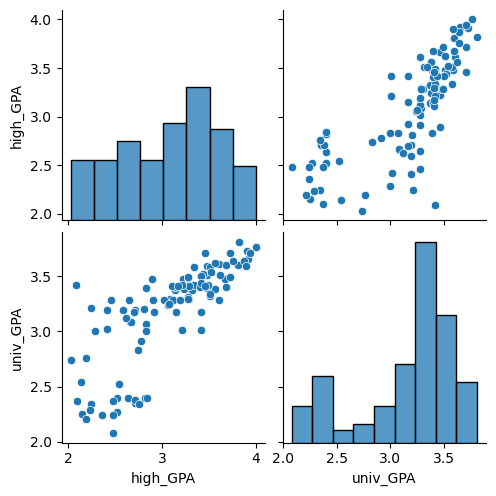

In [35]:
sn.pairplot(df)

## Create Input and Output Data

In [37]:
X = df.iloc[:,0:1].values
y = df.iloc[:,1:2].values

## Create Train and Test Sets

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,
                                                    random_state=0)

## K-Nearest Neighbours Modelling

### Train and Evaluate the KNN Model

In [45]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors = 5)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.16682311735262567

In [47]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test)
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

0.1810264761904762
0.3090476190476191


### Visualize the KNN Relationship

*Note this is possible with simple code because only 1 X and 1 y

In [50]:
X_sorted = np.sort(X_train, axis = 0)

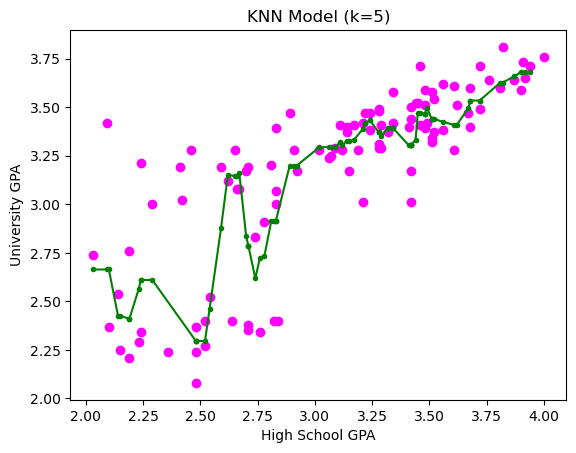

In [52]:
# Plot the provided points
plt.scatter(X, y, color = 'magenta') # the provided points

# Draw a line based on the predicted values of X_train
plt.plot(X_sorted, model.predict(X_sorted),
         color = 'green',
         marker = ".") 

# Add details
plt.title('KNN Model (k=5)')
plt.xlabel('High School GPA')
plt.ylabel('University GPA')
plt.show()

### Optimized KNN Regression Model

In [54]:
scores = []
nums = range(1,81)
best_knn = []
best_score_i = -1000

for i in nums:
    knn = KNeighborsRegressor(n_neighbors = i)
    knn.fit(X_train, y_train)
    score_i = knn.score(X_test, y_test)
    scores.append(score_i)
    
    if score_i > best_score_i:
        best_score_i = score_i
        best_knn = i

print(best_knn)

16


In [56]:
print(scores)

knn_val = max(scores)
best_knn = scores.index(knn_val) + 1
print(knn_val,best_knn)


[-0.1110687851450467, -0.00851491172774832, 0.00485125148024923, 0.06668413917334282, 0.16682311735262567, 0.3047464338344259, 0.37394717679676914, 0.45928337370534733, 0.5016354057517857, 0.5122900063871619, 0.5355103431627366, 0.5606580812213255, 0.5491324678967718, 0.560095272187934, 0.5874865612158706, 0.5967643009292694, 0.5821269211195645, 0.5600215151196081, 0.5713224210417382, 0.5639229256333937, 0.553480705223816, 0.5288201698150921, 0.510482474161752, 0.5162422234734478, 0.5180265973123828, 0.5200851451186628, 0.5286810753102589, 0.5159050160841989, 0.5256803552849247, 0.5222550578949642, 0.5281068966899395, 0.5267997107219526, 0.5367340777420881, 0.540529094385565, 0.5385148983093404, 0.534911483552555, 0.5360159880711746, 0.5363569901854782, 0.5339623853609942, 0.5326967039842536, 0.5308585075354041, 0.5320701939784942, 0.5261348996242072, 0.5194925508422494, 0.5132804533199873, 0.508501329922912, 0.5030465099997157, 0.4960734259263121, 0.48661788861343613, 0.47820993349836

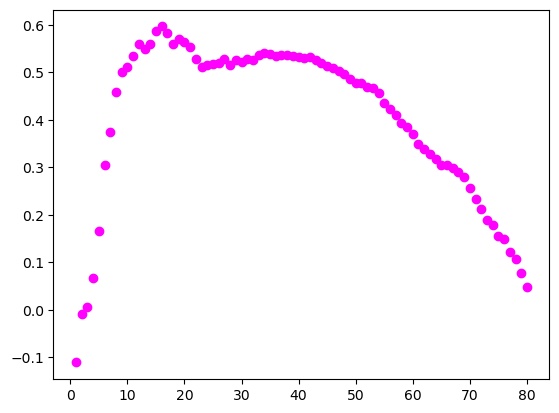

In [58]:
#Elbow Plot
plt.scatter(nums, scores, color = 'magenta')

### Train the Optimized KNN Model

In [60]:
knn_best = KNeighborsRegressor(n_neighbors = best_knn)
knn_best.fit(X_train, y_train)
knn_best.score(X_test, y_test)

0.5967643009292694

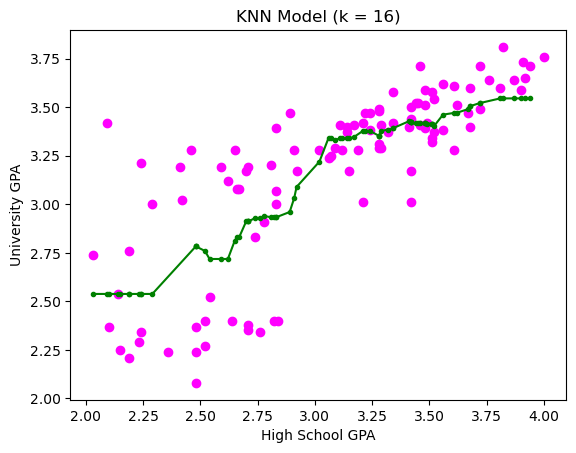

In [62]:
# Plot the provided points
plt.scatter(X, y, color = 'magenta') # the provided points

# Draw a line based on the predicted values of X_train
plt.plot(X_sorted, knn_best.predict(X_sorted),
         color = 'green',
         marker = ".") 

# Add details
plt.title(f'KNN Model (k = {best_knn})')
plt.xlabel('High School GPA')
plt.ylabel('University GPA')
plt.show()